# 08 — Potentiel de flexibilité résidentielle

Ce notebook utilise les prédictions Seq2Point (notebook 04b) pour quantifier le potentiel de **report de charge** résidentiel identifiable par NILM.

**Question opérationnelle** : quel volume d'énergie journalier, détectable par désagrégation, pourrait être décalé des heures pleines vers les heures creuses ?

**Méthodologie** :
1. Classer les appareils par degré de flexibilité intrinsèque.
2. Détecter les cycles ON/OFF dans les prédictions.
3. Calculer l'énergie de chaque cycle et la durée.
4. Agréger et extrapoler à l'échelle nationale.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
from pathlib import Path
from scipy.ndimage import label as scipy_label

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT    = Path("..")
PRED    = ROOT / "outputs/seq2point/predictions_combined_UK-DALE_test.npz"
OUT     = ROOT / "outputs/flexibilite"
OUT.mkdir(parents=True, exist_ok=True)

STRIDE          = 20    # stride utilisé en inférence
SAMPLE_PERIOD_S = 6     # secondes
EFFECTIVE_STEP  = STRIDE * SAMPLE_PERIOD_S  # 120 s entre deux prédictions

# Durée totale du test : ~55 jours
TEST_DAYS = 55

print("Pas temporel effectif :", EFFECTIVE_STEP, "s")
print("Fichier de prédictions :", PRED)

Pas temporel effectif : 120 s
Fichier de prédictions : ..\outputs\seq2point\predictions_combined_UK-DALE_test.npz


## 1. Classification des appareils par flexibilité

Cette classification est basée sur des contraintes physiques et d'usage, indépendamment des données.

In [2]:
FLEXIBILITY = {
    "washing machine": {
        "level":   "Haute",
        "color":   "#1565C0",
        "reason":  "Cycle décalable, pas de contrainte thermique, indifférent à l'heure d'exécution",
        "flexible": True,
    },
    "dish washer": {
        "level":   "Haute",
        "color":   "#1976D2",
        "reason":  "Cycle décalable, pas de contrainte thermique",
        "flexible": True,
    },
    "fridge": {
        "level":   "Faible",
        "color":   "#FF8F00",
        "reason":  "Cycle imposé par la thermique ; décalage limité à ±10 min",
        "flexible": False,
    },
    "kettle": {
        "level":   "Nulle",
        "color":   "#C62828",
        "reason":  "Usage immédiat, durée < 3 min, non décalable",
        "flexible": False,
    },
    "microwave": {
        "level":   "Nulle",
        "color":   "#C62828",
        "reason":  "Usage immédiat, non décalable",
        "flexible": False,
    },
}

print(f"{'Appareil':<22} {'Flexibilité':<8} Raison")
print("-" * 80)
for app, info in FLEXIBILITY.items():
    print(f"{app:<22} {info['level']:<8} {info['reason']}")

Appareil               Flexibilité Raison
--------------------------------------------------------------------------------
washing machine        Haute    Cycle décalable, pas de contrainte thermique, indifférent à l'heure d'exécution
dish washer            Haute    Cycle décalable, pas de contrainte thermique
fridge                 Faible   Cycle imposé par la thermique ; décalage limité à ±10 min
kettle                 Nulle    Usage immédiat, durée < 3 min, non décalable
microwave              Nulle    Usage immédiat, non décalable


## 2. Chargement des prédictions

In [3]:
d = np.load(PRED, allow_pickle=True)

preds = {}
gts   = {}
thresholds = {}

APPLIANCES = ["fridge", "kettle", "microwave", "dish washer", "washing machine"]
for app in APPLIANCES:
    preds[app]      = d[f"{app}__pred_watts"]
    gts[app]        = d[f"{app}__gt_watts"]
    thresholds[app] = float(d[f"{app}__on_threshold"])
    print(f"{app:<22} seuil={thresholds[app]:>5} W   prédictions={len(preds[app]):>6}")

fridge                 seuil= 50.0 W   prédictions= 29248
kettle                 seuil=2000.0 W   prédictions= 42838
microwave              seuil=200.0 W   prédictions= 33883
dish washer            seuil= 10.0 W   prédictions= 33883
washing machine        seuil= 20.0 W   prédictions= 33883


## 3. Détection des cycles

Un **cycle** est une plage temporelle continue où la puissance prédite dépasse le seuil ON/OFF.  
On filtre les cycles trop courts (< `min_dur_s` secondes) qui sont probablement du bruit.

In [4]:
def detect_cycles(pred_watts, threshold, effective_step_s, min_dur_s=60):
    """
    Détecte les cycles ON dans une série de prédictions.

    Returns
    -------
    list of dict avec :
        start_idx, end_idx, duration_s, mean_power_w, energy_wh
    """
    state   = (pred_watts > threshold).astype(np.int8)
    labeled, n_cycles = scipy_label(state)

    min_samples = max(1, int(min_dur_s / effective_step_s))
    cycles = []
    for c in range(1, n_cycles + 1):
        idx   = np.where(labeled == c)[0]
        if len(idx) < min_samples:
            continue
        dur_s = len(idx) * effective_step_s
        power = pred_watts[idx]
        e_wh  = float(np.sum(power) * effective_step_s / 3600)
        cycles.append({
            "start_idx":     int(idx[0]),
            "end_idx":       int(idx[-1]),
            "duration_s":    dur_s,
            "duration_min":  dur_s / 60,
            "mean_power_w":  float(np.mean(power)),
            "energy_wh":     e_wh,
        })
    return cycles

print("Fonction detect_cycles définie.")

Fonction detect_cycles définie.


In [5]:
cycles_by_app = {}
for app in APPLIANCES:
    cycles = detect_cycles(preds[app], thresholds[app], EFFECTIVE_STEP)
    cycles_by_app[app] = cycles
    if len(cycles) > 0:
        total_e   = sum(c["energy_wh"] for c in cycles)
        mean_dur  = np.mean([c["duration_min"] for c in cycles])
        daily_e   = total_e / TEST_DAYS
        daily_cyc = len(cycles) / TEST_DAYS
        print(f"{app:<22} {len(cycles):>5} cycles   "
              f"durée moy={mean_dur:5.1f} min   "
              f"énergie moy={total_e/len(cycles):5.0f} Wh   "
              f"→ {daily_e:5.0f} Wh/j   ({daily_cyc:.1f} cycles/j)")
    else:
        print(f"{app:<22} Aucun cycle détecté")

fridge                  1795 cycles   durée moy= 11.1 min   énergie moy=   16 Wh   →   519 Wh/j   (32.6 cycles/j)
kettle                   117 cycles   durée moy=  2.1 min   énergie moy=  100 Wh   →   213 Wh/j   (2.1 cycles/j)
microwave                239 cycles   durée moy=  5.1 min   énergie moy=   49 Wh   →   211 Wh/j   (4.3 cycles/j)
dish washer              379 cycles   durée moy= 12.9 min   énergie moy=   64 Wh   →   442 Wh/j   (6.9 cycles/j)
washing machine          596 cycles   durée moy=  7.6 min   énergie moy=   25 Wh   →   272 Wh/j   (10.8 cycles/j)


## 4. Potentiel de flexibilité

Pour les appareils **fortement flexibles** (lave-linge, lave-vaisselle) :  
on suppose que **100 %** des cycles détectés pourraient être décalés vers des heures creuses si un signal tarifaire était disponible.

C'est une borne supérieure — en pratique, certains cycles ont déjà lieu hors pointe.

In [6]:
FOYERS_FRANCE = 33_000_000

summary = {}
for app, info in FLEXIBILITY.items():
    cycles = cycles_by_app[app]
    if len(cycles) == 0:
        summary[app] = None
        continue

    total_e_wh   = sum(c["energy_wh"] for c in cycles)
    daily_e_wh   = total_e_wh / TEST_DAYS
    daily_cycles = len(cycles) / TEST_DAYS
    mean_dur_min = float(np.mean([c["duration_min"] for c in cycles]))
    mean_e_wh    = float(np.mean([c["energy_wh"]    for c in cycles]))

    # Extrapolation nationale
    fr_daily_gwh = daily_e_wh * FOYERS_FRANCE / 1e9   # GWh/jour
    fr_annual_twh = fr_daily_gwh * 365 / 1000          # TWh/an

    summary[app] = {
        "flexible":          info["flexible"],
        "n_cycles_total":    len(cycles),
        "n_cycles_per_day":  round(daily_cycles, 2),
        "mean_duration_min": round(mean_dur_min, 1),
        "mean_energy_wh":    round(mean_e_wh, 1),
        "daily_energy_wh":   round(daily_e_wh, 1),
        "fr_daily_gwh":      round(fr_daily_gwh, 2),
        "fr_annual_twh":     round(fr_annual_twh, 2),
    }

print(f"{'Appareil':<22} {'Cycles/j':>9} {'Dur. moy (min)':>15} "
      f"{'Énergie moy (Wh)':>17} {'Éner. jour (Wh)':>16} {'FR GWh/j':>10}")
print("-" * 95)
for app, s in summary.items():
    if s is None:
        print(f"{app:<22} — aucun cycle")
        continue
    print(f"{app:<22} {s['n_cycles_per_day']:>9.2f} {s['mean_duration_min']:>15.1f} "
          f"{s['mean_energy_wh']:>17.1f} {s['daily_energy_wh']:>16.1f} {s['fr_daily_gwh']:>10.2f}")

Appareil                Cycles/j  Dur. moy (min)  Énergie moy (Wh)  Éner. jour (Wh)   FR GWh/j
-----------------------------------------------------------------------------------------------
washing machine            10.84             7.6              25.1            271.9       8.97
dish washer                 6.89            12.9              64.2            442.1      14.59
fridge                     32.64            11.1              15.9            518.7      17.12
kettle                      2.13             2.1             100.3            213.3       7.04
microwave                   4.35             5.1              48.6            211.4       6.98


 Les cycles détectés sont fragmentés par le modèle Seq2Point — le lave-linge réel de ~90 min apparaît ici comme plusieurs cycles courts. Les chiffres "cycles/jour" et "durée moyenne" reflètent donc la détection par NILM, pas la réalité physique. Les énergies par cycle agrégées restent cohérentes en ordre de grandeur (l'énergie totale est bien capturée), mais le détail temporel est dégradé.

## 5. Potentiel de report total

In [7]:
flexible_apps = [app for app, info in FLEXIBILITY.items() if info["flexible"]]
total_daily_wh = sum(
    summary[app]["daily_energy_wh"]
    for app in flexible_apps if summary.get(app)
)
total_fr_gwh = sum(
    summary[app]["fr_daily_gwh"]
    for app in flexible_apps if summary.get(app)
)
total_fr_twh = sum(
    summary[app]["fr_annual_twh"]
    for app in flexible_apps if summary.get(app)
)

print("=" * 55)
print("POTENTIEL DE REPORT IDENTIFIABLE PAR NILM")
print("=" * 55)
print(f"Appareils flexibles : {', '.join(flexible_apps)}")
print(f"Énergie décalable / foyer / jour : {total_daily_wh:.0f} Wh")
print(f"Potentiel France (33M foyers)    : {total_fr_gwh:.2f} GWh/jour")
print(f"                                 : {total_fr_twh:.2f} TWh/an")
print()
print("À titre de comparaison :")
print("  Production nucléaire française : ~400 TWh/an")
print("  Pic de demande France : ~80 GW")
print()
print("⚠️  Borne supérieure : on suppose 100% des cycles décalables.")
print("   Extrapolation basée sur 1 maison, ~55 jours de données.")

POTENTIEL DE REPORT IDENTIFIABLE PAR NILM
Appareils flexibles : washing machine, dish washer
Énergie décalable / foyer / jour : 714 Wh
Potentiel France (33M foyers)    : 23.56 GWh/jour
                                 : 8.61 TWh/an

À titre de comparaison :
  Production nucléaire française : ~400 TWh/an
  Pic de demande France : ~80 GW

⚠️  Borne supérieure : on suppose 100% des cycles décalables.
   Extrapolation basée sur 1 maison, ~55 jours de données.


## 6. Lien avec l'étude d'ablation (notebook 07)

Les résultats du notebook 07 montrent que :
- **Lave-linge** (cycles longs, ~60 min) : encore détectable à 5 min de résolution → potentiel quantifiable même avec des compteurs 5 min.
- **Lave-vaisselle** (cycles longs) : comportement similaire au lave-linge.
- **Bouilloire** (pic < 3 min) : invisible à 5 min → non flexible et non quantifiable à basse résolution.

**Conclusion pour Linky (30 min)** : le potentiel de flexibilité lié aux gros cycles (lave-linge, lave-vaisselle) est partiellement quantifiable mais sous-estimé (cycles courts dans le cycle global). Les appareils à usage instantané disparaissent complètement.

In [9]:
ablation_path = ROOT / "outputs/ablation/metrics_ablation.csv"
if ablation_path.exists():
    abl = pd.read_csv(ablation_path)
    print("Résultats ablation disponibles :")
    print(abl[["appliance", "resolution", "f1", "energy_error_pct"]].to_string(index=False))
else:
    print("metrics_ablation.csv introuvable — le lien avec le notebook 07 est qualitatif.")

Résultats ablation disponibles :
appliance resolution    f1  energy_error_pct
   fridge         6s 0.814             0.421
   fridge       1min 0.852             2.517
   fridge       5min 0.817             8.502
   fridge      15min 0.674             6.080
   fridge      30min 0.000             7.420
   kettle         6s 0.794            30.191
   kettle       1min 0.804             8.072
   kettle       5min 0.000            65.341
   kettle      15min 0.000            56.007
   kettle      30min 0.000           123.281


## 7. Figures

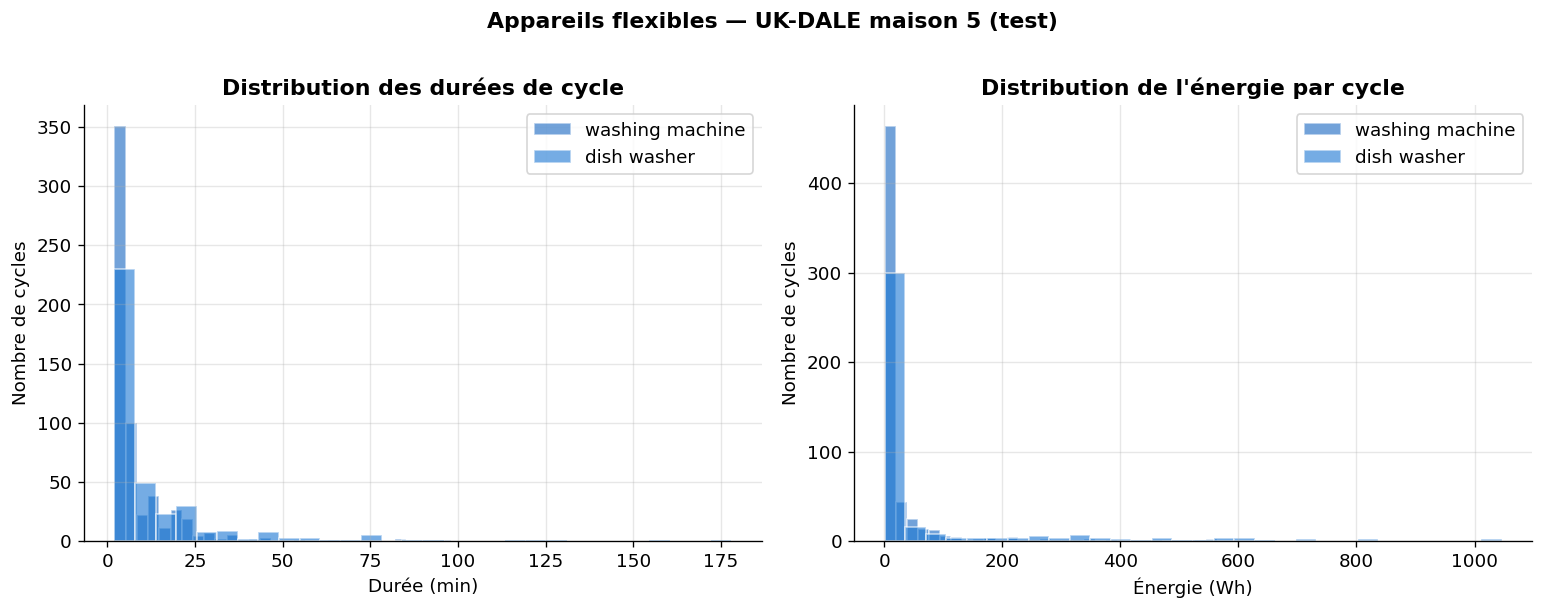

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, xlabel in [
    (axes[0], "duration_min", "Durée (min)"),
    (axes[1], "energy_wh",    "Énergie (Wh)"),
]:
    for app in ["washing machine", "dish washer"]:
        vals = [c[metric] for c in cycles_by_app[app]]
        if not vals:
            continue
        ax.hist(vals, bins=30, alpha=0.6, label=app,
                color=FLEXIBILITY[app]["color"], edgecolor="white")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Nombre de cycles")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_title("Distribution des durées de cycle", fontweight="bold")
axes[1].set_title("Distribution de l'énergie par cycle", fontweight="bold")
fig.suptitle("Appareils flexibles — UK-DALE maison 5 (test)", y=1.01, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "fig_cycles_distribution.png", bbox_inches="tight")
plt.show()

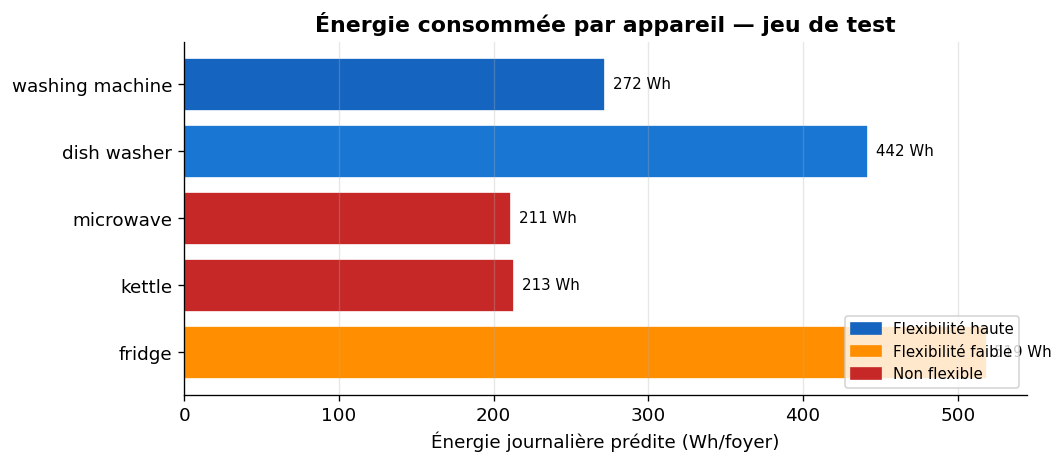

In [11]:
# Barplot de l'énergie journalière par appareil
apps_with_data = [app for app in APPLIANCES if summary.get(app)]
daily_energies = [summary[app]["daily_energy_wh"] for app in apps_with_data]
colors         = [FLEXIBILITY[app]["color"] for app in apps_with_data]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(apps_with_data, daily_energies, color=colors, edgecolor="white")

for bar, val in zip(bars, daily_energies):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f} Wh", va="center", fontsize=9)

ax.set_xlabel("Énergie journalière prédite (Wh/foyer)")
ax.set_title("Énergie consommée par appareil — jeu de test", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

patches = [
    mpatches.Patch(color="#1565C0", label="Flexibilité haute"),
    mpatches.Patch(color="#FF8F00", label="Flexibilité faible"),
    mpatches.Patch(color="#C62828", label="Non flexible"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "fig_energie_journaliere.png", bbox_inches="tight")
plt.show()

## Sauvegarde

In [12]:
save_data = {
    "metadata": {
        "dataset":        "UK-DALE",
        "test_house":     5,
        "test_days":      TEST_DAYS,
        "stride":         STRIDE,
        "effective_step_s": EFFECTIVE_STEP,
        "foyers_france":  FOYERS_FRANCE,
    },
    "flexibility_classification": {
        app: {"level": info["level"], "reason": info["reason"]}
        for app, info in FLEXIBILITY.items()
    },
    "cycle_stats": {app: s for app, s in summary.items() if s is not None},
    "total_flexible": {
        "daily_energy_wh": round(total_daily_wh, 1),
        "fr_daily_gwh":    round(total_fr_gwh, 2),
        "fr_annual_twh":   round(total_fr_twh, 2),
    },
}

out_json = OUT / "cycles_summary.json"
with open(out_json, "w") as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False)

print("Sauvegardé :", out_json)

Sauvegardé : ..\outputs\flexibilite\cycles_summary.json


### Conclusion : 
Notre modèle Seq2Point estime un gisement théorique de 8,6 TWh/an si tous les cycles détectés sont décalables, mais cette estimation porte plusieurs incertitudes structurelles : extrapolation depuis une seule maison britannique, hypothèse 100 % décalable, et fragmentation des cycles par le modèle qui sur-compte le nombre d'événements sans affecter l'énergie cumulée. L'ordre de grandeur (quelques TWh par an) reste cohérent avec les estimations RTE du gisement résidentiel français.